In [1]:
import seaborn as sns

BASE_FONTSIZE = 22
sns.set_theme(
    style="ticks",
    rc={
        "font.size": BASE_FONTSIZE,
        "axes.titlesize": BASE_FONTSIZE,
        "axes.labelsize": BASE_FONTSIZE,
        "xtick.labelsize": BASE_FONTSIZE * 0.85,
        "ytick.labelsize": BASE_FONTSIZE * 0.85,
        "legend.title_fontsize": BASE_FONTSIZE * 0.9,
        "legend.fontsize": BASE_FONTSIZE * 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "hatch.linewidth": 1.5,
        "hatch.color": "#333333",
    },
)


def apply_hatches(g, hatch_map):
    """Apply hatches by matching legend colors to bars."""
    # Build color -> hatch from legend
    color_to_hatch = {}
    for text, handle in zip(g._legend.get_texts(), g._legend.legend_handles):
        hatch = hatch_map.get(text.get_text(), None)
        if hatch:
            fc = handle.get_facecolor()
            color_to_hatch[tuple(fc)] = hatch

    # Apply to all bars
    for ax in g.axes.flat:
        for bar in ax.patches:
            hatch = color_to_hatch.get(tuple(bar.get_facecolor()))
            if hatch:
                bar.set_hatch(hatch)
                bar.set_edgecolor("#333333")

## Figure 4. Performance on ViT/T5

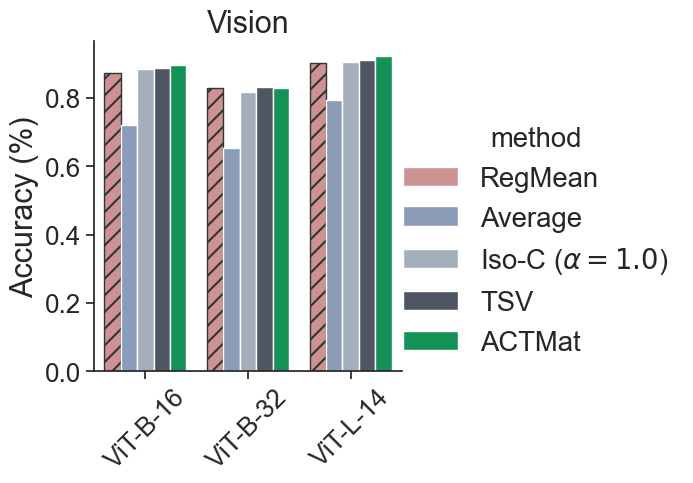

In [5]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns

methods = [
    "zeroshot",
    "experts",
    "regmean",
    "regmean-w",
    "fisher",
    "difisher",
    "difisher_v2",
    "sum04",
    "mean",
    "isoc",
    "isoc2",
    "isoc3",
    "tsv",
    "ace",
    "actmat",
]
models = ["ViT-B-16", "ViT-B-32", "ViT-L-14", "T5-Base", "T5-Large"]

method_to_method = {
    "zeroshot": "Zero-shot",
    "experts": "Experts",
    "regmean": "RegMean",
    "regmean-w": "RegMean-W",
    "fisher": "Fisher",
    "difisher": "DiFisher",
    "difisher_v2": "DiFisher-v2",
    "sum04": "TA ($\\alpha=0.4$)",
    "mean": "Average",
    "isoc": "Iso-C ($\\alpha=1.0$)",
    "isoc2": "Iso-C ($\\alpha=2.0$)",
    "isoc3": "Iso-C ($\\alpha=3.0$)",
    "tsv": "TSV",
    "actmat": "ACTMat",
    "ace": "ACE",
}

method_to_color = {
    # Base/Reference (Muted Gray)
    "Zero-shot": "#B0B0B0",
    # Group 1: Data-Dependent Methods (Muted Reds/Terracottas)
    "RegMean": "#D68A8A",
    "RegMean-W": "#B0E0E6",
    "Fisher": "#BA6B6B",
    "DiFisher": "#9DB7E5",
    "DiFisher-v2": "#9DB7E5",
    # Group 2: Merging/Ensembling Baselines (Muted Blues)
    "Experts": "#A3B7D9",
    "Average": "#829ABF",
    "TA ($\\alpha=0.4$)": "#637B9D",
    # Group 3: Task Vectors, Iso-C, and KNOTS Variants (Muted Slates)
    "Iso-C ($\\alpha=1.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=2.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=3.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "KNOTS-Iso-C": "#718096",  # (User specified)
    "TSV": "#4A5568",  # (User specified)
    "KNOTS-TSV": "#4A5568",  # (User specified) - Note: Use "#2D3748" if you need it darker/distinct
    # Group 4: ActMat (Muted Gold/Mustard)
    "ACE": "#6EE7B7",  # lighter green
    "ACTMat": "#00A658",
}

method_to_hatch = {
    "TA": "//",
    "RegMean": "//",
    "RegMean-W": "//",
    "Fisher": "\\",
}

method_to_linestyle = {
    "Experts": "-",
    "Zero-shot": ".",
}

model_to_group = {
    "ViT-B-16": "Vision",
    "ViT-B-32": "Vision",
    "ViT-L-14": "Vision",
    "T5-Base": "Language",
    "T5-Large": "Language",
}

rows = []
for model in models:
    for method in methods:

        filename = f"../results/{model}-{method}/metrics.json"
        if not os.path.exists(filename):
            continue

        # print(f"Loading {filename}")
        with open(filename, "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append({"model": model, "method": method, "acc": avg_score})


df = pd.DataFrame(rows)
df["group"] = df["model"].map(lambda x: model_to_group[x])
df["method"] = df["method"].map(lambda x: method_to_method[x])
# display(df)
g = sns.catplot(
    data=df,
    x="model",
    hue="method",
    y="acc",
    col="group",
    kind="bar",
    palette=method_to_color,
    sharex=False,
)
# Formatting.
g.set_axis_labels("", "Accuracy (%)")
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}", fontsize=BASE_FONTSIZE)

# # Legend.
# g._legend.remove()
# g.fig.legend(
#     *g.axes.flat[0].get_legend_handles_labels(),
#     loc="lower center",
#     ncol=4,
#     bbox_to_anchor=(0.5, -0.1),
#     title="",
#     frameon=False,
# )
# g.fig.subplots_adjust(bottom=0.35)
apply_hatches(g, method_to_hatch)
# apply_linestyles(g, method_to_linestyle)

In [6]:
dfp = df.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
# filter: only include methods with substring Iso-C
# dfp = dfp[dfp.index.str.contains("Iso-C")]
# Only include "Average" and "Fisher"
# dfp = dfp[dfp.index.isin(["Average", "Fisher", "DiFisher", "DiFisher-v2"])]
dfp.sort_values(by="ViT-B-16")

model,ViT-B-16,ViT-B-32,ViT-L-14
method,,,
Average,72.2,65.4,79.3
RegMean,87.2,83.0,90.1
Iso-C ($\alpha=1.0$),88.4,81.6,90.5
TSV,88.8,83.3,91.1
ACTMat,89.5,82.9,92.2


In [45]:
dfp = df.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
# filter: only include methods with substring Iso-C
# dfp = dfp[dfp.index.str.contains("Iso-C")]
# Only include "Average" and "Fisher"
dfp = dfp[dfp.index.isin(["RegMean", "RegMean-W"])]
dfp.sort_values(by="ViT-B-16")

model,T5-Base,T5-Large,ViT-B-16,ViT-B-32,ViT-L-14
method,,,,,
RegMean-W,74.6,74.9,74.3,78.8,77.6
RegMean,73.8,80.1,87.2,83.0,90.1
